# 02 - Exploratory Data Analysis (EDA)

This EDA notebook examines the cleaned datasets produced in `01_data_cleaning.ipynb`, aiming to unveil the structure, quality, and behavior of our relevant data before beginning any SQL querying, modeling, etc.

Here, we are going to load those cleaned datasets up and run some rudimentary quality checks. Then, we'll take a deeper dive into some distributions and relationships, visualize a few patterns, and identify any early business insights.

In [4]:
# First, we'll load up the cleaned data.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

clean_path = r"C:\Users\ednoo\Downloads\sales_pipeline_analysis\data\cleaned"

accounts = pd.read_csv(f"{clean_path}/accounts_clean.csv")
products = pd.read_csv(f"{clean_path}/products_clean.csv")
teams = pd.read_csv(f"{clean_path}/teams_clean.csv")
pipeline = pd.read_csv(f"{clean_path}/pipeline_clean.csv")

In [5]:
# And now we'll take a look at the first few rows of each:
accounts.head()

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN


In [6]:
products.head()

,product,series,sales_price
0,Gtx Basic,GTX,550
1,Gtx Pro,GTX,4821
2,Mg Special,MG,55
3,Mg Advanced,MG,3393
4,Gtx Plus Pro,GTX,5482


In [7]:
teams.head()

,sales_agent,manager,regional_office
0,Anna Snelling,Dustin Brinkmann,Central
1,Cecily Lampkin,Dustin Brinkmann,Central
2,Versie Hillebrand,Dustin Brinkmann,Central
3,Lajuana Vencill,Dustin Brinkmann,Central
4,Moses Frase,Dustin Brinkmann,Central


In [8]:
pipeline.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,Gtx Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,Gtx Pro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,Mg Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,Gtx Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,Gtx Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0


## Data Quality Checks

We can validate these cleaned datasets by checking a few things, such as missing values, duplicates, data types, unique values, and basic descriptive statistics.

In [9]:
# We'll start with accounts:
accounts.info()
accounts.isna().sum()
accounts.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   account           85 non-null     str    
 1   sector            85 non-null     str    
 2   year_established  85 non-null     int64  
 3   revenue           85 non-null     float64
 4   employees         85 non-null     int64  
 5   office_location   85 non-null     str    
 6   subsidiary_of     15 non-null     str    
dtypes: float64(1), int64(2), str(4)
memory usage: 4.8 KB


,account,sector,year_established,revenue,employees,office_location,subsidiary_of
count,85,85,85.000000,85.000000,85.000000,85,15
unique,85,10,NaN,NaN,NaN,15,7
top,Acme Corporation,retail,NaN,NaN,NaN,United States,Acme Corporation
freq,1,17,NaN,NaN,NaN,71,4
mean,NaN,NaN,1996.105882,1994.632941,4660.823529,NaN,NaN
std,NaN,NaN,8.865427,2169.491436,5715.601198,NaN,NaN
min,NaN,NaN,1979.000000,4.540000,9.000000,NaN,NaN
25%,NaN,NaN,1989.000000,497.110000,1179.000000,NaN,NaN
50%,NaN,NaN,1996.000000,1223.720000,2769.000000,NaN,NaN
75%,NaN,NaN,2002.000000,2741.370000,5595.000000,NaN,NaN


In [10]:
# Now products:
products.info()
products.isna().sum()
products.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   product      7 non-null      str  
 1   series       7 non-null      str  
 2   sales_price  7 non-null      int64
dtypes: int64(1), str(2)
memory usage: 300.0 bytes


,product,series,sales_price
count,7,7,7.000000
unique,7,3,NaN
top,Gtx Basic,GTX,NaN
freq,1,4,NaN
mean,NaN,NaN,6023.571429
std,NaN,NaN,9388.428070
min,NaN,NaN,55.000000
25%,NaN,NaN,823.000000
50%,NaN,NaN,3393.000000
75%,NaN,NaN,5151.500000


In [11]:
# Teams next:
teams.info()
teams.isna().sum()
teams.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   sales_agent      35 non-null     str  
 1   manager          35 non-null     str  
 2   regional_office  35 non-null     str  
dtypes: str(3)
memory usage: 972.0 bytes


,sales_agent,manager,regional_office
count,35,35,35
unique,35,6,3
top,Anna Snelling,Melvin Marxen,East
freq,1,6,12


In [12]:
# Lastly, pipeline:
pipeline.info()
pipeline.isna().sum()
pipeline.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   opportunity_id  8800 non-null   str    
 1   sales_agent     8800 non-null   str    
 2   product         8800 non-null   str    
 3   account         7375 non-null   str    
 4   deal_stage      8800 non-null   str    
 5   engage_date     8300 non-null   str    
 6   close_date      6711 non-null   str    
 7   close_value     6711 non-null   float64
dtypes: float64(1), str(7)
memory usage: 550.1 KB


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
count,8800,8800,8800,7375,8800,8300,6711,6711.000000
unique,8800,30,7,85,4,421,306,NaN
top,1C1I7A6R,Darcel Schlecht,Gtx Basic,Hottechi,Won,2017-07-22,2017-05-22,NaN
freq,1,747,1866,200,4238,66,41,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1490.915512
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2320.670773
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,472.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3225.000000


## Exploratory Visuals

Here we'll take a look at some distributions, relationships, and patterns to get behind the behavior of customers, products, etc.

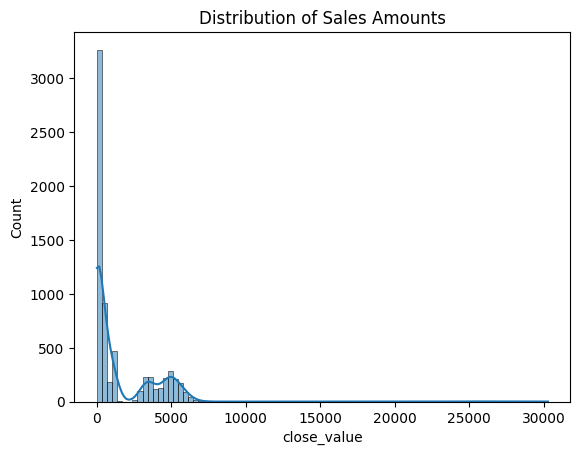

In [13]:
# We'll start off simple with the distribution of sales amounts.
sns.histplot(pipeline["close_value"], kde=True)
plt.title("Distribution of Sales Amounts")
plt.show()

In [ ]:
# Most sales are <$5000.
# Though, some push.

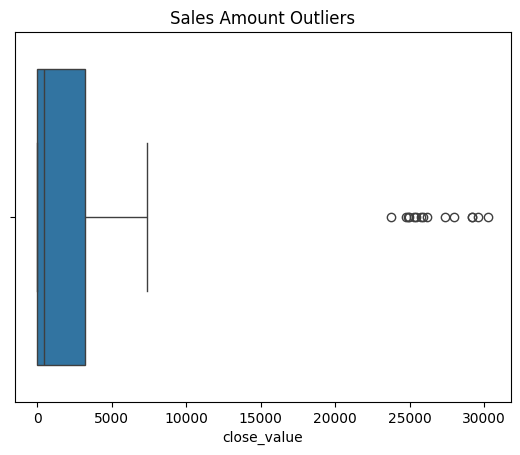

In [14]:
# Let's look at an outlier boxplot.
sns.boxplot(x=pipeline["close_value"])
plt.title("Sales Amount Outliers")
plt.show()

In [ ]:
# This clears it up.
# Those outliers are sales of the most valuable product ($22,000+).

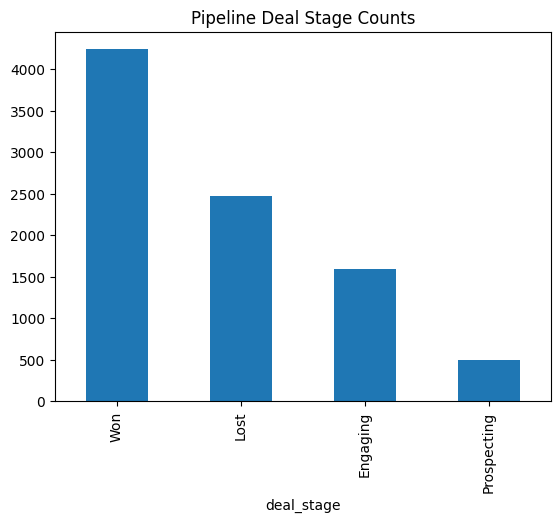

In [15]:
# Let's look at our various opportunity categories.
pipeline["deal_stage"].value_counts().plot(kind="bar")
plt.title("Pipeline Deal Stage Counts")
plt.show()

In [ ]:
# Looks like the vast majority of "opportunities" here are closed.
# More opportunities have won than have lost.
# Looks like we've got 1500-2000 currently engaged opportunities, and ~500 prospecting.

## Early Business Questions

Here we'll ask a few exploratory questions that help guide the deeper analysis we'll take to SQL.

#### Which products sell the most?

In [21]:
pipeline.groupby("product")["close_value"].sum().sort_values(ascending=False)

product
Gtx Pro           3510578.0
Gtx Plus Pro      2629651.0
Mg Advanced       2216387.0
Gtx Plus Basic     705275.0
Gtx Basic          499263.0
Gtk 500            400612.0
Mg Special          43768.0
Name: close_value, dtype: float64

#### Which sales agents close the most deals?

In [23]:
pipeline[pipeline["deal_stage"] == "Won"]["sales_agent"].value_counts().head(10)

sales_agent
Darcel Schlecht       349
Vicki Laflamme        221
Kary Hendrixson       209
Anna Snelling         208
Versie Hillebrand     176
Kami Bicknell         174
Jonathan Berthelot    171
Cassey Cress          163
Zane Levy             161
Donn Cantrell         158
Name: count, dtype: int64

#### What are the pipeline's opportunity proportions?

In [24]:
pipeline["deal_stage"].value_counts(normalize=True)

deal_stage
Won            0.481591
Lost           0.281023
Engaging       0.180568
Prospecting    0.056818
Name: proportion, dtype: float64

#### What does monthly revenue look like?

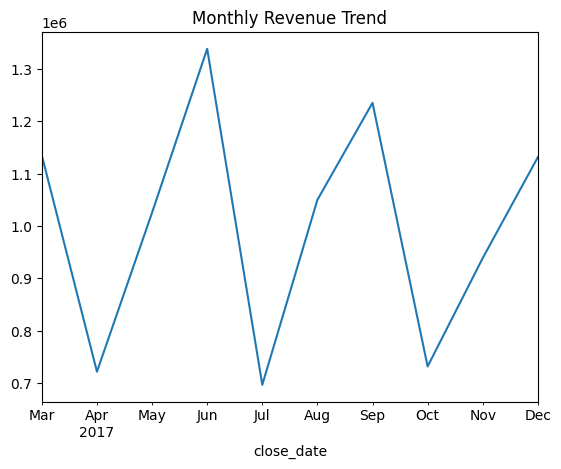

In [30]:
pipeline["close_date"] = pd.to_datetime(pipeline["close_date"])
pipeline.groupby(pipeline["close_date"].dt.to_period("M"))["close_value"].sum().plot()
plt.title("Monthly Revenue Trend")
plt.show()